# Tuberculosis Incidence Prediction model (Linear regression) :
This is my first Ml project based upon the supervised learning model i.e linear regression. Even though this is my first project, I have used real world dataset to make it standarized and useful for researcher and any other organizations working on this field. As a public health background I have combinded both my health knowledge and ML skills to make this project more interesting. This project is open to anyone who wants to makes some positive changes on it.

# 1. First, I downloaded the TB dataset from the WHO website (link ; https://www.who.int/teams/global-tuberculosis-programme/data?utm_source=chatgpt.com). After that, I performed the following steps:

In [279]:
# Importing the important Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [280]:
# mounting the google drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [281]:
import requests
import pandas as pd


# 1. World Bank indicators
indicators = {
    "NY.GDP.PCAP.CD": "gdp_per_capita",
    "EN.POP.DNST": "population_density",
    "SP.URB.TOTL.IN.ZS": "urban_population",
    "SH.DYN.AIDS.ZS": "hiv_prevalence",
    "SH.XPD.CHEX.GD.ZS": "health_expenditure"
}


# 2. Create an empty list
all_data = []


# 3. Download each indicator
for code, name in indicators.items():

    url = f"https://api.worldbank.org/v2/country/all/indicator/{code}?format=json&per_page=20000"

    response = requests.get(url)

    data = response.json()

    records = data[1]


    # 4. Convert data to a DataFrame
    df = pd.DataFrame(records)


    # 5. Keep only the columns we need
    df = df[["countryiso3code", "date", "value"]]

    df.columns = ["iso3", "year", name]


    # 6. Convert year to number
    df["year"] = df["year"].astype(int)


    # 7. Keep 2000–2025
    df = df[df["year"].between(2000, 2025)]


    # 8. Remove missing values
    df = df.dropna(subset=[name])


    # 9. Remove duplicate country-year records
    df = df.drop_duplicates(["iso3", "year"])


    # 10. Add the DataFrame to our list
    all_data.append(df)


# 11. Start with the first indicator
world_bank = all_data[0]


# 12. Add the other indicators
for df in all_data[1:]:

    world_bank = world_bank.merge(
        df,
        on=["iso3", "year"],
        how="outer"
    )


# 13. Sort the data
world_bank = world_bank.sort_values(["iso3", "year"])


# 14. Look at the result
print(world_bank.head())

print("Shape:", world_bank.shape)

  iso3  year  gdp_per_capita  population_density  urban_population  \
0       2000    22428.172607           24.157574         76.124359   
1       2001    22129.018998           24.281185         76.383580   
2       2002    22974.359265           24.405878         76.705729   
3       2003    25642.099866           24.533526         77.060638   
4       2004    28482.304279           24.667423         77.409597   

   hiv_prevalence  health_expenditure  
0        2.872809            9.345211  
1        2.818668            9.816382  
2        2.723797           10.242479  
3        2.624634           10.405755  
4        2.547690           10.326212  
Shape: (6786, 7)


# Saving the Dataset

In [282]:
# Data saving
world_bank.to_csv("/content/drive/MyDrive/Colab Notebooks/world_bank.csv")

# Loading the TB Dataset  and WorldbanK Dataset from google drive

In [361]:
import pandas as pd

# Load TB data with specific columns
tb = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/world_tb.csv",
    usecols=['country', 'iso2', 'iso3', 'g_whoregion', 'year', 'e_pop_num', 'e_inc_100k', 'e_inc_100k_lo', 'e_inc_100k_hi']
)

# Load World Bank data
world_bank = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/world_bank.csv").drop(columns=['Unnamed: 0'])


In [284]:
tb.head(5)


,country,iso2,iso3,g_whoregion,year,e_pop_num,e_inc_100k,e_inc_100k_lo,e_inc_100k_hi
0,Afghanistan,AF,AFG,EMR,2000,20130323,148.0,46.0,1510.0
1,Afghanistan,AF,AFG,EMR,2001,20284311,175.0,66.0,1320.0
2,Afghanistan,AF,AFG,EMR,2002,21378110,197.0,83.0,1140.0
3,Afghanistan,AF,AFG,EMR,2003,22733047,215.0,97.0,992.0
4,Afghanistan,AF,AFG,EMR,2004,23560660,228.0,109.0,862.0


In [285]:
world_bank.head(3)

,iso3,year,gdp_per_capita,population_density,urban_population,hiv_prevalence,health_expenditure
0,NaN,2000,22428.172607,24.157574,76.124359,2.872809,9.345211
1,NaN,2001,22129.018998,24.281185,76.383580,2.818668,9.816382
2,NaN,2002,22974.359265,24.405878,76.705729,2.723797,10.242479


In [286]:
tb.duplicated().sum()

np.int64(0)

In [287]:
tb.isnull().sum()

,0
country,0
iso2,25
iso3,0
g_whoregion,0
year,0
e_pop_num,0
e_inc_100k,25
e_inc_100k_lo,25
e_inc_100k_hi,25


In [288]:
tb.dropna()

,country,iso2,iso3,g_whoregion,year,e_pop_num,e_inc_100k,e_inc_100k_lo,e_inc_100k_hi
0,Afghanistan,AF,AFG,EMR,2000,20130323,148.0,46.0,1510.0
1,Afghanistan,AF,AFG,EMR,2001,20284311,175.0,66.0,1320.0
2,Afghanistan,AF,AFG,EMR,2002,21378110,197.0,83.0,1140.0
3,Afghanistan,AF,AFG,EMR,2003,22733047,215.0,97.0,992.0
4,Afghanistan,AF,AFG,EMR,2004,23560660,228.0,109.0,862.0
...,...,...,...,...,...,...,...,...,...
5342,Zimbabwe,ZW,ZWE,AFR,2020,15526885,189.0,137.0,248.0
5343,Zimbabwe,ZW,ZWE,AFR,2021,15797209,198.0,139.0,257.0
5344,Zimbabwe,ZW,ZWE,AFR,2022,16069054,209.0,144.0,277.0
5345,Zimbabwe,ZW,ZWE,AFR,2023,16340822,209.0,138.0,280.0


# World bank dataset

In [289]:
world_bank.head()

,iso3,year,gdp_per_capita,population_density,urban_population,hiv_prevalence,health_expenditure
0,NaN,2000,22428.172607,24.157574,76.124359,2.872809,9.345211
1,NaN,2001,22129.018998,24.281185,76.383580,2.818668,9.816382
2,NaN,2002,22974.359265,24.405878,76.705729,2.723797,10.242479
3,NaN,2003,25642.099866,24.533526,77.060638,2.624634,10.405755
4,NaN,2004,28482.304279,24.667423,77.409597,2.547690,10.326212


In [290]:
world_bank.duplicated().sum()

np.int64(0)

In [291]:
world_bank.isnull().sum()

,0
iso3,26
year,0
gdp_per_capita,214
population_density,617
urban_population,0
hiv_prevalence,2392
health_expenditure,1166


In [292]:
# percentage of missing columns
world_bank.isnull().mean()*100

,0
iso3,0.383142
year,0.000000
gdp_per_capita,3.153551
population_density,9.092249
urban_population,0.000000
hiv_prevalence,35.249042
health_expenditure,17.182434


# Merging the both dataset

In [362]:
# important #
df = tb.merge(world_bank, on=['iso3', 'year'], how='inner')

In [363]:
df.head()

,country,iso2,iso3,g_whoregion,year,e_pop_num,e_inc_100k,e_inc_100k_lo,e_inc_100k_hi,gdp_per_capita,population_density,urban_population,hiv_prevalence,health_expenditure
0,Afghanistan,AF,AFG,EMR,2000,20130323,148.0,46.0,1510.0,174.930991,30.863847,18.558200,0.1,NaN
1,Afghanistan,AF,AFG,EMR,2001,20284311,175.0,66.0,1320.0,138.706822,31.099929,18.741238,0.1,NaN
2,Afghanistan,AF,AFG,EMR,2002,21378110,197.0,83.0,1140.0,178.954088,32.776961,18.941248,0.1,9.443391
3,Afghanistan,AF,AFG,EMR,2003,22733047,215.0,97.0,992.0,198.871116,34.854344,19.160035,0.1,8.941258
4,Afghanistan,AF,AFG,EMR,2004,23560660,228.0,109.0,862.0,221.763654,36.123230,19.399359,0.1,9.808474


In [364]:
df.isnull().mean()*100

,0
country,0.000000
iso2,0.482439
iso3,0.000000
g_whoregion,0.000000
year,0.000000
e_pop_num,0.000000
e_inc_100k,0.482439
e_inc_100k_lo,0.482439
e_inc_100k_hi,0.482439
gdp_per_capita,2.026245


In [365]:
df.head()

,country,iso2,iso3,g_whoregion,year,e_pop_num,e_inc_100k,e_inc_100k_lo,e_inc_100k_hi,gdp_per_capita,population_density,urban_population,hiv_prevalence,health_expenditure
0,Afghanistan,AF,AFG,EMR,2000,20130323,148.0,46.0,1510.0,174.930991,30.863847,18.558200,0.1,NaN
1,Afghanistan,AF,AFG,EMR,2001,20284311,175.0,66.0,1320.0,138.706822,31.099929,18.741238,0.1,NaN
2,Afghanistan,AF,AFG,EMR,2002,21378110,197.0,83.0,1140.0,178.954088,32.776961,18.941248,0.1,9.443391
3,Afghanistan,AF,AFG,EMR,2003,22733047,215.0,97.0,992.0,198.871116,34.854344,19.160035,0.1,8.941258
4,Afghanistan,AF,AFG,EMR,2004,23560660,228.0,109.0,862.0,221.763654,36.123230,19.399359,0.1,9.808474


In [366]:
df.groupby('year')[
    ['gdp_per_capita', 'population_density', 'hiv_prevalence', 'health_expenditure']
].apply(lambda x: x.isna().sum())

,gdp_per_capita,population_density,hiv_prevalence,health_expenditure
year,,,,
2000,7,1,57,20
2001,6,1,57,20
2002,3,1,57,20
2003,3,1,57,18
2004,3,1,57,18
2005,3,3,57,19
2006,2,1,57,19
2007,2,1,57,19
2008,2,1,57,19


In [367]:
df.groupby('iso3')[
    ['gdp_per_capita', 'population_density', 'hiv_prevalence', 'health_expenditure']
].apply(lambda x: x.isna().sum())

,gdp_per_capita,population_density,hiv_prevalence,health_expenditure
iso3,,,,
ABW,0,1,25,25
AFG,0,1,0,3
AGO,0,1,0,1
ALB,0,1,0,1
AND,0,1,25,1
...,...,...,...,...
WSM,0,1,25,1
YEM,6,1,0,1
ZAF,0,1,0,1


In [368]:
before = len(df)

after = len(
    df.dropna(
        subset=[
            "gdp_per_capita",
            "population_density",
            "urban_population",
            "hiv_prevalence",
            "health_expenditure"
        ]
    )
)

print("Before:", before)
print("After:", after)
print("Dropped:", before - after)

Before: 5182
After: 3497
Dropped: 1685


In [369]:
df = df.dropna(
    subset=[
        'e_inc_100k',
        'gdp_per_capita',
        'population_density',
        'urban_population',
        'hiv_prevalence',
        'health_expenditure'
    ]
)

In [370]:
df

,country,iso2,iso3,g_whoregion,year,e_pop_num,e_inc_100k,e_inc_100k_lo,e_inc_100k_hi,gdp_per_capita,population_density,urban_population,hiv_prevalence,health_expenditure
2,Afghanistan,AF,AFG,EMR,2002,21378110,197.0,83.0,1140.0,178.954088,32.776961,18.941248,0.1,9.443391
3,Afghanistan,AF,AFG,EMR,2003,22733047,215.0,97.0,992.0,198.871116,34.854344,19.160035,0.1,8.941258
4,Afghanistan,AF,AFG,EMR,2004,23560660,228.0,109.0,862.0,221.763654,36.123230,19.399359,0.1,9.808474
5,Afghanistan,AF,AFG,EMR,2005,24404569,237.0,118.0,754.0,254.184249,37.417118,19.705910,0.1,9.948289
6,Afghanistan,AF,AFG,EMR,2006,25424099,242.0,124.0,662.0,274.218554,38.980258,20.110453,0.1,10.622766
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5176,Zimbabwe,ZW,ZWE,AFR,2019,15271376,199.0,147.0,258.0,2184.521554,39.476200,36.183764,12.5,3.232682
5177,Zimbabwe,ZW,ZWE,AFR,2020,15526885,189.0,137.0,248.0,2059.637040,40.136714,37.009767,12.0,2.954401
5178,Zimbabwe,ZW,ZWE,AFR,2021,15797209,198.0,139.0,257.0,2613.616741,40.835492,37.869206,11.5,2.671119
5179,Zimbabwe,ZW,ZWE,AFR,2022,16069054,209.0,144.0,277.0,2536.401971,41.538209,38.705521,10.9,3.395195


In [371]:
df.isnull().sum()

,0
country,0
iso2,24
iso3,0
g_whoregion,0
year,0
e_pop_num,0
e_inc_100k,0
e_inc_100k_lo,0
e_inc_100k_hi,0
gdp_per_capita,0


In [303]:
df.shape

(3497, 14)

In [304]:
df

,country,iso2,iso3,g_whoregion,year,e_pop_num,e_inc_100k,e_inc_100k_lo,e_inc_100k_hi,gdp_per_capita,population_density,urban_population,hiv_prevalence,health_expenditure
2,Afghanistan,AF,AFG,EMR,2002,21378110,197.0,83.0,1140.0,178.954088,32.776961,18.941248,0.1,9.443391
3,Afghanistan,AF,AFG,EMR,2003,22733047,215.0,97.0,992.0,198.871116,34.854344,19.160035,0.1,8.941258
4,Afghanistan,AF,AFG,EMR,2004,23560660,228.0,109.0,862.0,221.763654,36.123230,19.399359,0.1,9.808474
5,Afghanistan,AF,AFG,EMR,2005,24404569,237.0,118.0,754.0,254.184249,37.417118,19.705910,0.1,9.948289
6,Afghanistan,AF,AFG,EMR,2006,25424099,242.0,124.0,662.0,274.218554,38.980258,20.110453,0.1,10.622766
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5176,Zimbabwe,ZW,ZWE,AFR,2019,15271376,199.0,147.0,258.0,2184.521554,39.476200,36.183764,12.5,3.232682
5177,Zimbabwe,ZW,ZWE,AFR,2020,15526885,189.0,137.0,248.0,2059.637040,40.136714,37.009767,12.0,2.954401
5178,Zimbabwe,ZW,ZWE,AFR,2021,15797209,198.0,139.0,257.0,2613.616741,40.835492,37.869206,11.5,2.671119
5179,Zimbabwe,ZW,ZWE,AFR,2022,16069054,209.0,144.0,277.0,2536.401971,41.538209,38.705521,10.9,3.395195


# basic ML workflow first.

# Step 1 — Create the modeling dataset

Use your five predictors:

In [335]:
predictors = [
    "gdp_per_capita",
    "population_density",
    "urban_population",
    "hiv_prevalence",
    "health_expenditure"
]

target = "e_inc_100k"


# Step 3 — Define X and y

In [306]:
X = df[predictors]
y = df[target]

In [307]:
print(X.shape)
print(y.shape)

(3497, 5)
(3497,)


# Great. Now we move to EDA (Exploratory Data Analysis).

In [308]:
df.head()

,country,iso2,iso3,g_whoregion,year,e_pop_num,e_inc_100k,e_inc_100k_lo,e_inc_100k_hi,gdp_per_capita,population_density,urban_population,hiv_prevalence,health_expenditure
2,Afghanistan,AF,AFG,EMR,2002,21378110,197.0,83.0,1140.0,178.954088,32.776961,18.941248,0.1,9.443391
3,Afghanistan,AF,AFG,EMR,2003,22733047,215.0,97.0,992.0,198.871116,34.854344,19.160035,0.1,8.941258
4,Afghanistan,AF,AFG,EMR,2004,23560660,228.0,109.0,862.0,221.763654,36.123230,19.399359,0.1,9.808474
5,Afghanistan,AF,AFG,EMR,2005,24404569,237.0,118.0,754.0,254.184249,37.417118,19.705910,0.1,9.948289
6,Afghanistan,AF,AFG,EMR,2006,25424099,242.0,124.0,662.0,274.218554,38.980258,20.110453,0.1,10.622766


In [309]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3497 entries, 2 to 5180
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   country             3497 non-null   object 
 1   iso2                3473 non-null   object 
 2   iso3                3497 non-null   object 
 3   g_whoregion         3497 non-null   object 
 4   year                3497 non-null   int64  
 5   e_pop_num           3497 non-null   int64  
 6   e_inc_100k          3497 non-null   float64
 7   e_inc_100k_lo       3497 non-null   float64
 8   e_inc_100k_hi       3497 non-null   float64
 9   gdp_per_capita      3497 non-null   float64
 10  population_density  3497 non-null   float64
 11  urban_population    3497 non-null   float64
 12  hiv_prevalence      3497 non-null   float64
 13  health_expenditure  3497 non-null   float64
dtypes: float64(8), int64(2), object(4)
memory usage: 409.8+ KB


In [310]:
df.describe()

,year,e_pop_num,e_inc_100k,e_inc_100k_lo,e_inc_100k_hi,gdp_per_capita,population_density,urban_population,hiv_prevalence,health_expenditure
count,3497.000000,3.497000e+03,3497.000000,3497.000000,3497.000000,3497.000000,3497.000000,3497.000000,3497.000000,3497.000000
mean,2011.621962,2.280300e+07,166.890663,100.942428,310.251478,11632.207092,188.620248,55.229997,1.757821,5.947621
std,6.897174,4.018688e+07,234.145028,136.302440,751.878892,19008.171584,630.701396,22.799434,4.209815,2.656016
min,2000.000000,9.540000e+03,0.000000,0.000000,0.000000,109.593814,1.543388,8.043814,0.100000,1.326516
25%,2006.000000,2.500082e+06,19.000000,15.000000,22.000000,1127.160779,25.351018,35.348765,0.100000,3.947554
50%,2012.000000,8.425553e+06,75.000000,52.000000,105.000000,3813.726074,72.237712,55.689926,0.300000,5.356537
75%,2018.000000,2.302577e+07,219.000000,134.000000,370.000000,11734.764974,140.097904,73.412503,1.300000,7.721799
max,2023.000000,2.811901e+08,2700.000000,2200.000000,23500.000000,134965.815442,8241.849582,100.000000,29.400000,27.089685


# 4.2 Check the target distribution

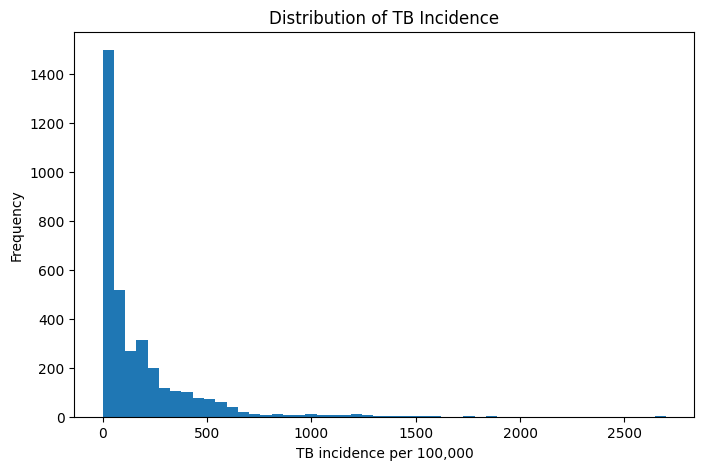

In [311]:
y = df["e_inc_100k"]

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(y, bins=50)
plt.xlabel("TB incidence per 100,000")
plt.ylabel("Frequency")
plt.title("Distribution of TB Incidence")
plt.show()

# 4.3 Check outliers

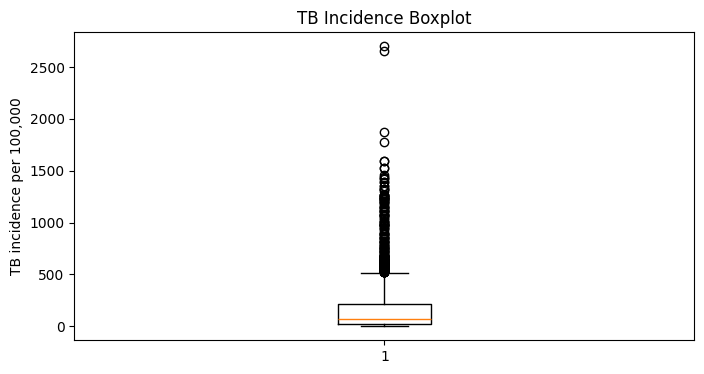

In [312]:
plt.figure(figsize=(8, 4))
plt.boxplot(y)
plt.ylabel("TB incidence per 100,000")
plt.title("TB Incidence Boxplot")
plt.show()

# 4.4 Look at correlations

This is one of the most important EDA steps for our project.

In [313]:
corr = df[predictors + [target]].corr()

corr

,gdp_per_capita,population_density,urban_population,hiv_prevalence,health_expenditure,e_inc_100k
gdp_per_capita,1.000000,0.192469,0.571100,-0.172337,0.311674,-0.325352
population_density,0.192469,1.000000,0.175903,-0.073219,-0.038691,-0.091420
urban_population,0.571100,0.175903,1.000000,-0.246976,0.257642,-0.356238
hiv_prevalence,-0.172337,-0.073219,-0.246976,1.000000,0.039209,0.612510
health_expenditure,0.311674,-0.038691,0.257642,0.039209,1.000000,-0.163252
e_inc_100k,-0.325352,-0.091420,-0.356238,0.612510,-0.163252,1.000000


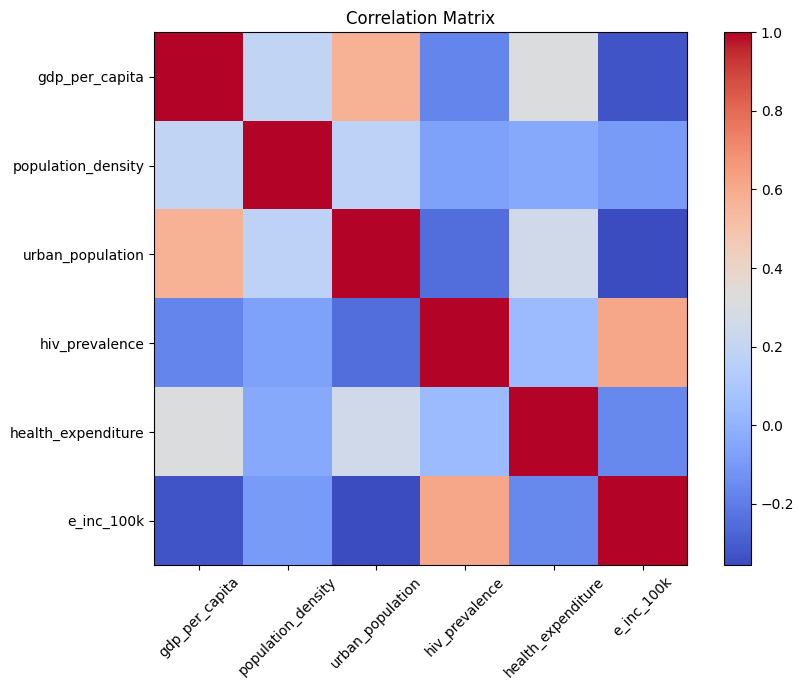

In [314]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 7))
plt.imshow(corr, cmap="coolwarm", interpolation="none")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# 4.5 Scatterplots — predictor vs TB incidence

Let’s visually examine each relationship.

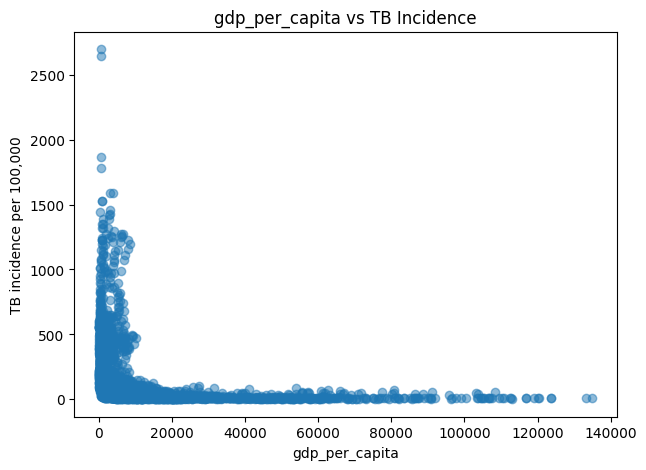

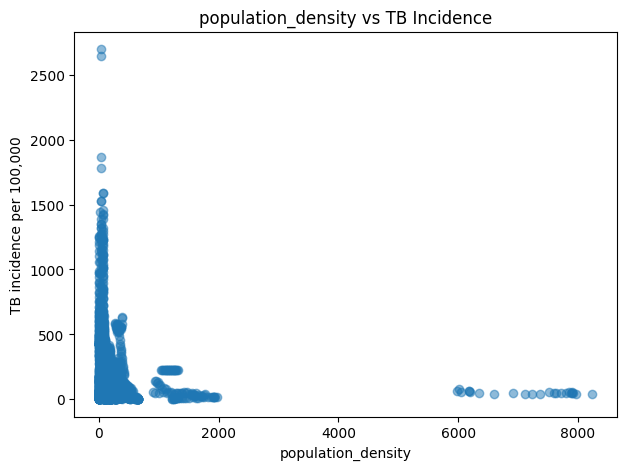

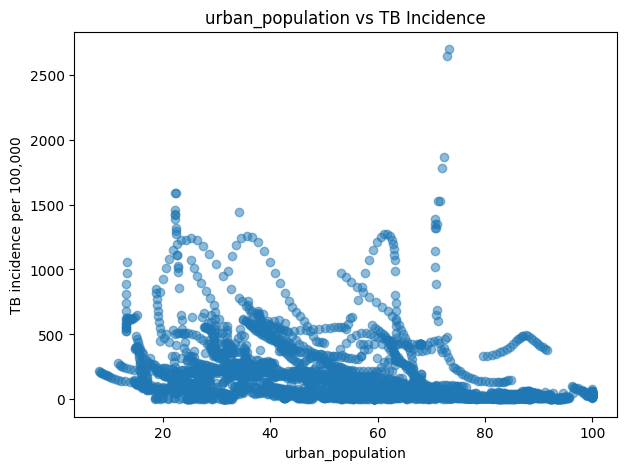

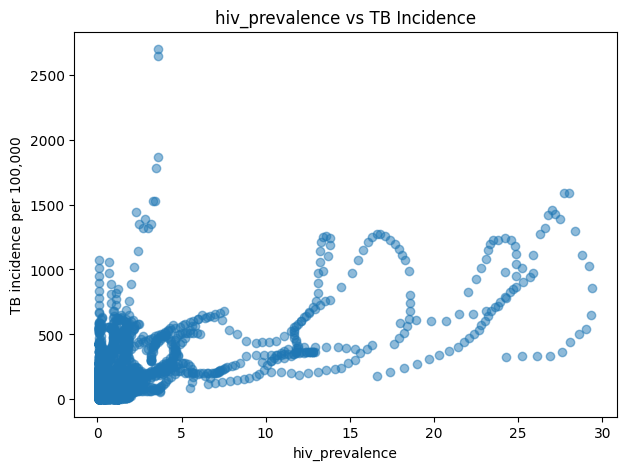

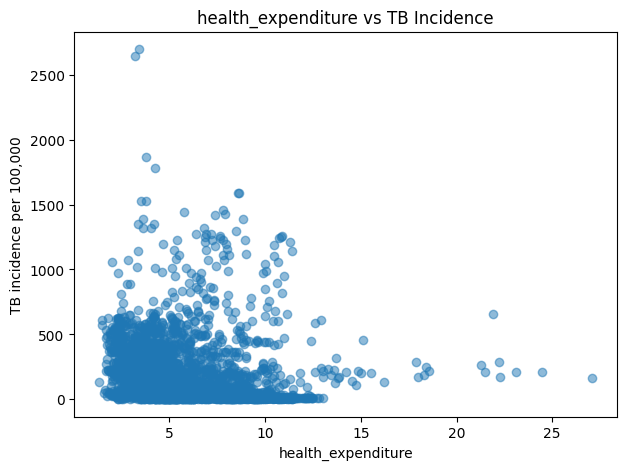

In [315]:
for col in predictors:
    plt.figure(figsize=(7, 5))
    plt.scatter(df[col], df["e_inc_100k"], alpha=0.5)
    plt.xlabel(col)
    plt.ylabel("TB incidence per 100,000")
    plt.title(f"{col} vs TB Incidence")
    plt.show()

In [316]:
X.corr()

,gdp_per_capita,population_density,urban_population,hiv_prevalence,health_expenditure
gdp_per_capita,1.000000,0.192469,0.571100,-0.172337,0.311674
population_density,0.192469,1.000000,0.175903,-0.073219,-0.038691
urban_population,0.571100,0.175903,1.000000,-0.246976,0.257642
hiv_prevalence,-0.172337,-0.073219,-0.246976,1.000000,0.039209
health_expenditure,0.311674,-0.038691,0.257642,0.039209,1.000000


# Now we’re ready for the first ML step: Train/Test Split

In [317]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [318]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2797, 5)
X_test: (700, 5)
y_train: (2797,)
y_test: (700,)


# Step 8 — Train Linear Regression

In [319]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [320]:
y_pred = model.predict(X_test)

In [321]:
y_pred = model.predict(X_test)

In [322]:
print(y_pred[:10])

[158.77681377 198.37004949 203.67333182 191.37626353 126.48754226
 199.75659533 156.32168362 348.2477487   11.29740093 -16.50432696]


In [323]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(comparison.head(10))

   Actual   Predicted
0  170.00  158.776814
1  275.00  198.370049
2  338.00  203.673332
3  236.00  191.376264
4    0.71  126.487542
5  129.00  199.756595
6   67.00  156.321684
7  564.00  348.247749
8    9.80   11.297401
9    9.50  -16.504327


In [333]:
from sklearn.metrics import mean_absolute_error,root_mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [334]:
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 106.13722246258172
RMSE: 167.07892595791097
R²: 0.5201068488472258


# Another way With Log transfer

In [372]:
X = df[predictors]
y_log = np.log1p(df["e_inc_100k"])

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log,
    test_size=0.2,
    random_state=42
)

model_log_y = LinearRegression()
model_log_y.fit(X_train, y_train_log)

y_pred_log = model_log_y.predict(X_test)

# Convert predictions back to TB incidence
y_pred = np.expm1(y_pred_log)
y_test = np.expm1(y_test_log)

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 106.01662851256428
RMSE: 220.9556424778148
R²: 0.16071126259433766
